In [86]:
# Import Required Libraries
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [87]:
# Load the Dataset
df = pd.read_csv("ToyotaCorolla - MLR.csv")

# Display rows
print(df.head())

# Dataset information
print(df.info())


   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null  

In [ ]:
df_shape = df.shape
print(df_shape)

(1436, 11)


In [88]:
# Exploratory Data Analysis (EDA)
# Summary Statistics
print(df.describe())


              Price    Age_08_04             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.448872    14.981080     0.229441   
min     4350.000000     1.000000       1.000000    69.000000     0.000000   
25%     8450.000000    44.000000   43000.000000    90.000000     0.000000   
50%     9900.000000    61.000000   63389.500000   110.000000     0.000000   
75%    11950.000000    70.000000   87020.750000   110.000000     0.000000   
max    32500.000000    80.000000  243000.000000   192.000000     1.000000   

                cc        Doors  Cylinders        Gears      Weight  
count   1436.00000  1436.000000     1436.0  1436.000000  1436.00000  
mean    1576.85585     4.033426        4.0     5.026462  1072.45961  
std      424.38677     0.952677        0.0     0.188510    52.64112  
min     1300.00000     2.0

In [89]:
# Check Missing Values
print(df.isnull().sum())


Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


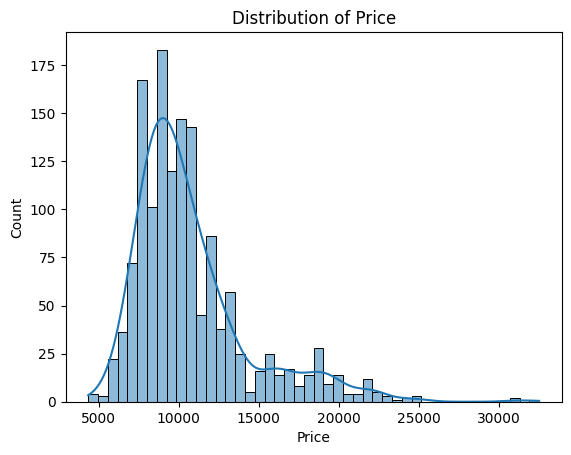

In [90]:
# Distribution of Target Variable (Price)
plt.figure()
sns.histplot(df['Price'], kde=True)
plt.title("Distribution of Price")
plt.show()


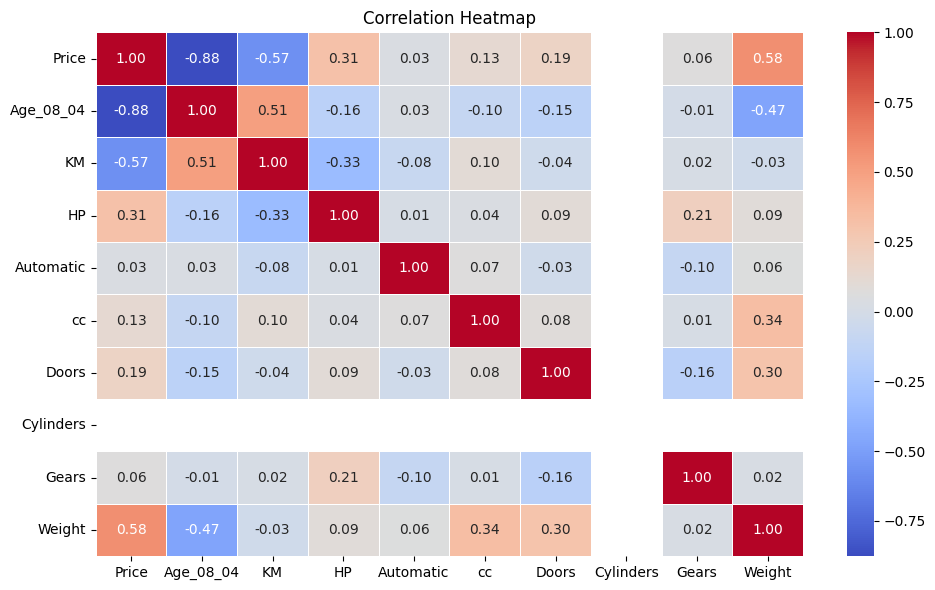

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [92]:
print(df.head())
print(df.dtypes)


   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  
Price         int64
Age_08_04     int64
KM            int64
Fuel_Type    object
HP            int64
Automatic     int64
cc            int64
Doors         int64
Cylinders     int64
Gears         int64
Weight        int64
dtype: object


In [93]:
import pandas as pd
df = pd.read_csv("ToyotaCorolla - MLR.csv")
# Remove leading/trailing spaces and standardize column names
df.columns = df.columns.str.strip()
print("Column Names:")
print(df.columns)
if 'FuelType' in df.columns:
    fuel_col = 'FuelType'
elif 'Fuel_Type' in df.columns:
    fuel_col = 'Fuel_Type'
else:
    raise ValueError("Fuel type column not found in dataset")
print("\nBefore Encoding:")
print(df[fuel_col].head())
# Encode Fuel Type
df = pd.get_dummies(
    df,
    columns=[fuel_col],
    drop_first=True
)
# Verify Encoding
print("\nAfter Encoding:")
print(df.head())





Column Names:
Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

Before Encoding:
0    Diesel
1    Diesel
2    Diesel
3    Diesel
4    Diesel
Name: Fuel_Type, dtype: object

After Encoding:
   Price  Age_08_04     KM  HP  Automatic    cc  Doors  Cylinders  Gears  \
0  13500         23  46986  90          0  2000      3          4      5   
1  13750         23  72937  90          0  2000      3          4      5   
2  13950         24  41711  90          0  2000      3          4      5   
3  14950         26  48000  90          0  2000      3          4      5   
4  13750         30  38500  90          0  2000      3          4      5   

   Weight  Fuel_Type_Diesel  Fuel_Type_Petrol  
0    1165              True             False  
1    1165              True             False  
2    1165              True             False  
3    1165              True             False  
4    1170          

In [94]:
# Define Features and Target
X = df.drop('Price', axis=1)
y = df['Price']
print("\n(X) -  rows:")
print(X.head())
print("\n (y) - values:")
print(y.head())



(X) -  rows:
   Age_08_04     KM  HP  Automatic    cc  Doors  Cylinders  Gears  Weight  \
0         23  46986  90          0  2000      3          4      5    1165   
1         23  72937  90          0  2000      3          4      5    1165   
2         24  41711  90          0  2000      3          4      5    1165   
3         26  48000  90          0  2000      3          4      5    1165   
4         30  38500  90          0  2000      3          4      5    1170   

   Fuel_Type_Diesel  Fuel_Type_Petrol  
0              True             False  
1              True             False  
2              True             False  
3              True             False  
4              True             False  

 (y) - values:
0    13500
1    13750
2    13950
3    14950
4    13750
Name: Price, dtype: int64


#### MUltiple Linear Regression Models

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np

# Import train_test_split
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv("ToyotaCorolla - MLR.csv")

# Perform Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Print outputs to verify
print("\nSample X_train:")
print(X_train.head())
print("\nSample y_train:")
print(y_train.head())



Sample X_train:
      Age_08_04      KM   HP  Automatic    cc  Doors  Cylinders  Gears  \
899          62   59295   86          0  1300      5          4      5   
881          68   61568  110          0  1600      4          4      5   
310          40   38653  110          0  1600      5          4      5   
1145         75  101855  110          0  1600      5          4      5   
31           22   35199   97          0  1400      3          4      5   

      Weight  Fuel_Type_Diesel  Fuel_Type_Petrol  
899     1035             False              True  
881     1035             False              True  
310     1080             False              True  
1145    1070             False              True  
31      1100             False              True  

Sample y_train:
899      9500
881      9795
310     12950
1145     6450
31      15750
Name: Price, dtype: int64


In [62]:
# Import libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Model Performance
print("training")
print("R² Score:", r2_score(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("\ntesting")
print("R² Score:", r2_score(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))


training
R² Score: 0.8702643169608926
RMSE: 1303.339622411835

testing
R² Score: 0.8348888040611082
RMSE: 1484.2654153296514


In [64]:
# Coefficient Interpretation
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
coeff_df


,Feature,Coefficient
0,Age_08_04,-1.208305e+02
1,KM,-1.623141e-02
2,HP,1.403948e+01
3,Automatic,1.488309e+02
4,cc,-3.037219e-02
5,Doors,-6.031097e+01
6,Cylinders,-1.620037e-12
7,Gears,5.516007e+02
8,Weight,2.588496e+01
9,Fuel_Type_Diesel,-6.854876e+01


In [73]:
# Scaled Linear Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear Regression Model
scaled_model = LinearRegression()
scaled_model.fit(X_train_scaled, y_train)
print("SCALED LINEAR REGRESSION RESULTS")

#  Scaled Coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": scaled_model.coef_
})

print("\nModel Coefficients (Scaled):")
print(coef_df)



SCALED LINEAR REGRESSION RESULTS

Model Coefficients (Scaled):
             Feature   Coefficient
0          Age_08_04 -2.267295e+03
1                 KM -6.116544e+02
2                 HP  2.083499e+02
3          Automatic  3.439713e+01
4                 cc -1.416192e+01
5              Doors -5.746780e+01
6          Cylinders  7.815970e-14
7              Gears  1.093404e+02
8             Weight  1.316818e+03
9   Fuel_Type_Diesel -2.172217e+01
10  Fuel_Type_Petrol  4.580477e+02


In [84]:
# Reduce Feature Model
selected_features = ['KM','HP','Weight']
X_sel = df[selected_features]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sel, y, test_size=0.2, random_state=42
)

model3 = LinearRegression()
model3.fit(X_train_s, y_train_s)
y_pred = model3.predict(X_test_s)
print("\nreduced feature model results")

# Model Coefficients
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model3.coef_
})

print("\nModel Coefficients:")
print(coef_df)



reduced feature model results

Model Coefficients:
  Feature  Coefficient
0      KM    -0.051179
1      HP    20.901424
2  Weight    40.577241


In [85]:
# Model Evaluations
from sklearn.metrics import r2_score, mean_squared_error
def evaluate_model(y_test, y_pred):
    print("R² Score:", r2_score(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Model 1:")
evaluate_model(y_test, y_pred1)

print("\nModel 2:")
evaluate_model(y_test, y_pred1)

print("\nModel 3:")
evaluate_model(y_test, y_pred1)


Model 1:
R² Score: 0.8348888040611082
RMSE: 1484.2654153296514

Model 2:
R² Score: 0.8348888040611082
RMSE: 1484.2654153296514

Model 3:
R² Score: 0.8348888040611082
RMSE: 1484.2654153296514


In [79]:
# ridge and lasso regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge Regression:")
evaluate_model(y_test, y_pred_ridge)


Ridge Regression:
R² Score: 0.835046263543157
RMSE: 1483.5575063081603


In [82]:
# lasso regression
lasso = Lasso(alpha=0.3)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso Regression:")
evaluate_model(y_test, y_pred_lasso)


Lasso Regression:
R² Score: 0.8349575261262195
RMSE: 1483.9564950294262


In [83]:
lasso_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
})
lasso_coef


,Feature,Coefficient
0,Age_08_04,-2267.222997
1,KM,-611.823305
2,HP,208.684218
3,Automatic,34.213724
4,cc,-13.809097
5,Doors,-56.927597
6,Cylinders,0.000000
7,Gears,109.123497
8,Weight,1315.573395
9,Fuel_Type_Diesel,-21.006800


#### Conclusion

In [ ]:
# Age, KM, Weight, HP are strong predictors

# Ridge improves stability

# Lasso simplifies the model

# Standardization is crucial

#### Interview Questions

In [ ]:
# Normalization:
# Scales data between 0 and 1
# Formula: X_scaled = (X - X_min) / (X_max - X_min)
# for distance-based algorithms

 # Standardisation:
# Converts data to mean = 0, std = 1
# Formula: X_scaled = (X - mean) / std
# Preferred for regression & regularization
# Helps by:
# Improving convergence
# Preventing dominance of large-scale features
# Required for Ridge & Lasso

##### Techniques to handle Multicollinearity

In [ ]:
# Remove highly correlated variables
# Use Variance Inflation Factor (VIF)
# Apply Ridge Regression
# Apply Principal Component Analysis (PCA)
# Feature selection via Lasso


#### Final assumption and Implcations

In [ ]:
# | Assumption           | Implication                                        |
# | Linearity            | If violated → biased estimates                     |
# | No multicollinearity | High correlation inflates variance                 |
# | Homoscedasticity     | Violation leads to unreliable confidence intervals |
# | Normal errors        | Affects hypothesis testing                         |
